# ДЗ 8. ELSA: точное softmax-внимание за линейное время



## Конфиг


In [1]:
# !pip install torch numpy matplotlib scikit-learn

import gc
import time
import math
import urllib.request
import zipfile
import io

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

DTYPE = torch.float32
D = 64
TILE = 128
SEQ_LENS = [128, 256, 512, 1024, 2048, 4096, 8192, 16384]

print("device:", device, "| dtype:", DTYPE)
print("head dim D:", D, "| tile:", TILE)

device: mps | dtype: torch.float32
head dim D: 64 | tile: 128


### Внимание $O(n^2)$

In [2]:
def standard_attn(q, k, v, causal=False):
    scale = q.shape[-1] ** -0.5
    logits = (q @ k.transpose(-2, -1)) * scale
    if causal:
        n = q.shape[-2]
        mask = torch.triu(torch.ones(n, n, device=q.device, dtype=torch.bool), diagonal=1)
        logits = logits.masked_fill(mask, float("-inf"))
    return torch.softmax(logits, dim=-1) @ v

### ELSA - точный softmax за O(N)


In [3]:
def elsa_attn(q, k, v, tile=TILE, causal=False):
    B, n, d = q.shape
    dv = v.shape[-1]
    scale = d ** -0.5

    m_run = torch.full((B, n, 1), float("-inf"), device=q.device, dtype=q.dtype)
    s_run = torch.zeros((B, n, 1), device=q.device, dtype=q.dtype)
    w_run = torch.zeros((B, n, dv), device=q.device, dtype=q.dtype)

    pos = torch.arange(n, device=q.device)
    for start in range(0, n, tile):
        end = min(start + tile, n)
        k_tile = k[:, start:end, :]
        v_tile = v[:, start:end, :]
        raw = (q @ k_tile.transpose(-2, -1)) * scale

        if causal:
            future = pos[start:end].unsqueeze(0) > pos.unsqueeze(1)
            raw = raw.masked_fill(future.unsqueeze(0), float("-inf"))

        m_tile = raw.max(dim=-1, keepdim=True).values
        m_new = torch.maximum(m_run, m_tile)
        alpha = torch.exp(m_run - m_new)
        p = torch.exp(raw - m_new)

        w_run = alpha * w_run + p @ v_tile
        s_run = alpha * s_run + p.sum(dim=-1, keepdim=True)
        m_run = m_new

    return w_run / s_run.clamp(min=1e-20)

### FAVOR+ приближённое внимание

In [4]:
def orthogonal_features(num_features, dim, device, dtype):
    blocks = []
    remaining = num_features
    while remaining > 0:
        g = torch.randn(dim, dim, device=device, dtype=dtype)
        q_mat, _ = torch.linalg.qr(g)
        blocks.append(q_mat.T)
        remaining -= dim
    proj = torch.cat(blocks, dim=0)[:num_features]
    norms = torch.randn(num_features, dim, device=device, dtype=dtype).norm(dim=1)
    return proj * norms.unsqueeze(1)


def favor_attn(q, k, v, num_features=256):
    d = q.shape[-1]
    scale = d ** -0.25
    q = q * scale
    k = k * scale
    proj = orthogonal_features(num_features, d, q.device, q.dtype)

    def phi(x):
        proj_x = x @ proj.T
        norm = (x * x).sum(dim=-1, keepdim=True) / 2
        return torch.exp(proj_x - norm) / math.sqrt(num_features)

    qf = phi(q)
    kf = phi(k)
    kv = kf.transpose(-2, -1) @ v
    num = qf @ kv
    den = qf @ kf.sum(dim=-2, keepdim=True).transpose(-2, -1)
    return num / den.clamp(min=1e-6)

## Проверка
ELSA должен совпасть со standard, FAVOR+ должен приблизить.
Проверим независимость elsa от размера тайла

In [5]:
def max_abs_err(a, b):
    return (a - b).abs().max().item()

torch.manual_seed(SEED)
qe = torch.randn(2, 512, D, device=device, dtype=DTYPE)
ke = torch.randn(2, 512, D, device=device, dtype=DTYPE)
ve = torch.randn(2, 512, D, device=device, dtype=DTYPE)

y_std = standard_attn(qe, ke, ve)
y_elsa = elsa_attn(qe, ke, ve)
y_favor = favor_attn(qe, ke, ve)

print(f"max|standard - ELSA|  = {max_abs_err(y_std, y_elsa):.3e}")
print(f"max|standard - FAVOR+| = {max_abs_err(y_std, y_favor):.3e}")

assert torch.allclose(y_std, y_elsa, atol=1e-4), "ELSA должна совпадать со стандартным softmax"
print("\nassert пройден: ELSA == standard softmax (atol=1e-4)")

print("\nИнвариантность ELSA к размеру тайла:")
for t in [16, 32, 64, 128, 256]:
    err = max_abs_err(y_std, elsa_attn(qe, ke, ve, tile=t))
    print(f"  tile={t:>4}: max|standard - ELSA| = {err:.3e}")

max|standard - ELSA|  = 2.831e-07
max|standard - FAVOR+| = 2.097e+00

assert пройден: ELSA == standard softmax (atol=1e-4)

Инвариантность ELSA к размеру тайла:
  tile=  16: max|standard - ELSA| = 2.831e-07
  tile=  32: max|standard - ELSA| = 3.278e-07
  tile=  64: max|standard - ELSA| = 2.831e-07
  tile= 128: max|standard - ELSA| = 2.831e-07
  tile= 256: max|standard - ELSA| = 3.129e-07


In [6]:
qc = torch.randn(1, 256, D, device=device, dtype=DTYPE)
kc = torch.randn(1, 256, D, device=device, dtype=DTYPE)
vc = torch.randn(1, 256, D, device=device, dtype=DTYPE)

err_causal = max_abs_err(standard_attn(qc, kc, vc, causal=True),
                         elsa_attn(qc, kc, vc, causal=True))
print(f"Каузальный путь: max|standard - ELSA| = {err_causal:.3e}")
assert err_causal < 1e-4
print("assert пройден: каузальная ELSA == каузальный softmax")

Каузальный путь: max|standard - ELSA| = 5.364e-07
assert пройден: каузальная ELSA == каузальный softmax


## Ошибка эквивалентности от длины последовательности


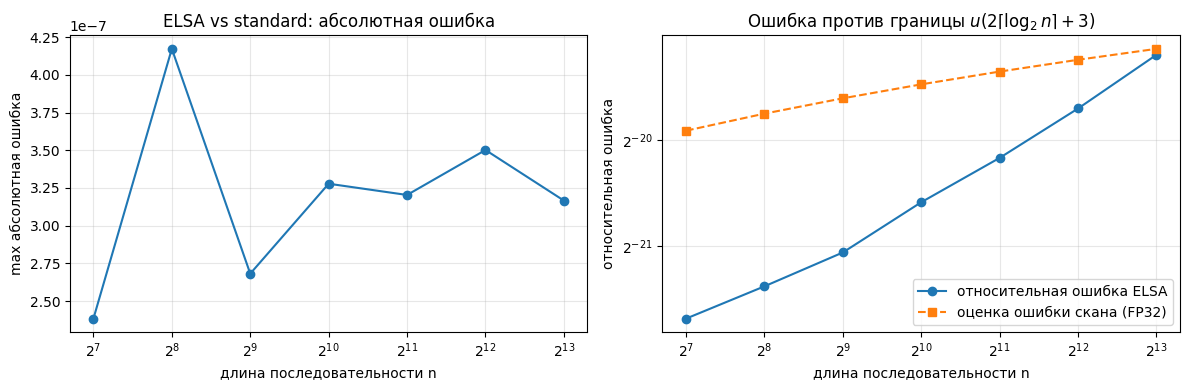

max |standard-ELSA| = 4.17e-07  |  max отн. ошибка = 1.66e-06


In [7]:
u_fp32 = torch.finfo(torch.float32).eps / 2

err_ns = [128, 256, 512, 1024, 2048, 4096, 8192]
abs_errs, rel_errs, bound = [], [], []
for n in err_ns:
    torch.manual_seed(n)
    q = torch.randn(1, n, D, device=device, dtype=DTYPE)
    k = torch.randn(1, n, D, device=device, dtype=DTYPE)
    v = torch.randn(1, n, D, device=device, dtype=DTYPE)
    ys = standard_attn(q, k, v)
    ye = elsa_attn(q, k, v)
    abs_errs.append((ys - ye).abs().max().item())
    rel_errs.append(((ys - ye).norm() / ys.norm()).item())
    bound.append(u_fp32 * (2 * math.ceil(math.log2(n)) + 3))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].semilogx(err_ns, abs_errs, "o-", base=2)
ax[0].set_xlabel("длина последовательности n")
ax[0].set_ylabel("max абсолютная ошибка")
ax[0].set_title("ELSA vs standard: абсолютная ошибка")
ax[0].grid(True, alpha=0.3)

ax[1].loglog(err_ns, rel_errs, "o-", base=2, label="относительная ошибка ELSA")
ax[1].loglog(err_ns, bound, "s--", base=2, label="оценка ошибки скана (FP32)")
ax[1].set_xlabel("длина последовательности n")
ax[1].set_ylabel("относительная ошибка")
ax[1].set_title("Ошибка против границы $u(2\\lceil\\log_2 n\\rceil+3)$")
ax[1].legend()
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"max |standard-ELSA| = {max(abs_errs):.2e}  |  max отн. ошибка = {max(rel_errs):.2e}")

## бенч по скорости и памяти


In [8]:
def sync():
    if device == "cuda":
        torch.cuda.synchronize()

def peak_mb():
    if device == "cuda":
        return torch.cuda.max_memory_allocated() / 1024 ** 2
    return float("nan")

def bench(fn, n, iters=10, warmup=3):
    q = torch.randn(1, n, D, device=device, dtype=DTYPE)
    k = torch.randn(1, n, D, device=device, dtype=DTYPE)
    v = torch.randn(1, n, D, device=device, dtype=DTYPE)
    try:
        for _ in range(warmup):
            fn(q, k, v)
        sync()
        if device == "cuda":
            torch.cuda.reset_peak_memory_stats()
        t0 = time.perf_counter()
        for _ in range(iters):
            fn(q, k, v)
        sync()
        latency = (time.perf_counter() - t0) / iters * 1000
        mem = peak_mb()
    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            latency, mem = float("nan"), float("nan")
            if device == "cuda":
                torch.cuda.empty_cache()
        else:
            raise
    del q, k, v
    gc.collect()
    if device == "cuda":
        torch.cuda.empty_cache()
    return latency, mem

methods = {
    "standard": standard_attn,
    "ELSA": lambda q, k, v: elsa_attn(q, k, v),
    "FAVOR+": lambda q, k, v: favor_attn(q, k, v),
}

lat = {m: [] for m in methods}
mem = {m: [] for m in methods}
for n in SEQ_LENS:
    row = []
    for name, fn in methods.items():
        l, mm = bench(fn, n)
        lat[name].append(l)
        mem[name].append(mm)
        row.append(f"{name} {l:7.2f}ms" + ("" if math.isnan(mm) else f"/{mm:7.1f}MB"))
    print(f"n={n:6d} | " + " | ".join(row))

n=   128 | standard    0.09ms | ELSA    0.17ms | FAVOR+    4.21ms
n=   256 | standard    0.09ms | ELSA    0.30ms | FAVOR+    3.50ms
n=   512 | standard    0.09ms | ELSA    0.56ms | FAVOR+    6.80ms
n=  1024 | standard    0.10ms | ELSA    1.20ms | FAVOR+    4.46ms
n=  2048 | standard    0.09ms | ELSA    4.30ms | FAVOR+    4.40ms
n=  4096 | standard    0.11ms | ELSA   12.50ms | FAVOR+    4.19ms
n=  8192 | standard    0.12ms | ELSA   52.90ms | FAVOR+    5.45ms
n= 16384 | standard    0.10ms | ELSA  228.15ms | FAVOR+    7.98ms


## Графики

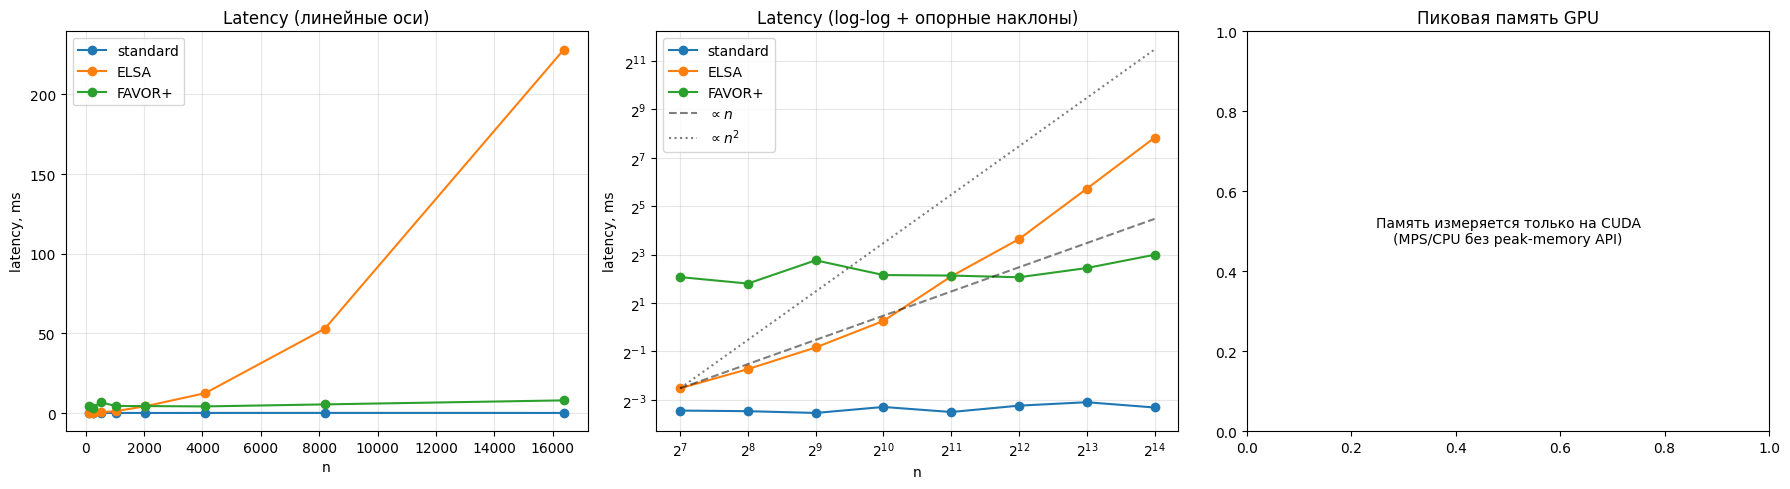

In [ ]:
def clean(xs, ys):
    px = [x for x, y in zip(xs, ys) if not math.isnan(y)]
    py = [y for y in ys if not math.isnan(y)]
    return px, py

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

for name in methods:
    px, py = clean(SEQ_LENS, lat[name])
    ax[0].plot(px, py, "o-", label=name)
ax[0].set_xlabel("n")
ax[0].set_ylabel("latency, ms")
ax[0].set_title("Latency (линейные оси)")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

for name in methods:
    px, py = clean(SEQ_LENS, lat[name])
    ax[1].loglog(px, py, "o-", base=2, label=name)
ref = [SEQ_LENS[0], SEQ_LENS[-1]]
base_lat = next(y for y in lat["ELSA"] if not math.isnan(y))
ax[1].loglog(ref, [base_lat, base_lat * ref[1] / ref[0]], "k--", base=2, alpha=0.5, label="$\\propto n$")
ax[1].loglog(ref, [base_lat, base_lat * (ref[1] / ref[0]) ** 2], "k:", base=2, alpha=0.5, label="$\\propto n^2$")
ax[1].set_xlabel("n")
ax[1].set_ylabel("latency, ms")
ax[1].set_title("Latency (log-log + опорные наклоны)")
ax[1].legend()
ax[1].grid(True, alpha=0.3, which="both")


plt.tight_layout()
plt.show()

Память на mps не измеряется

## Датасет UCI HAR

In [10]:
HAR_URL = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"

def load_har():
    raw = urllib.request.urlopen(HAR_URL, timeout=60).read()
    outer = zipfile.ZipFile(io.BytesIO(raw))
    inner = zipfile.ZipFile(io.BytesIO(outer.read("UCI HAR Dataset.zip")))

    def read(name):
        with inner.open(name) as f:
            return np.loadtxt(f)

    xtr = read("UCI HAR Dataset/train/X_train.txt")
    ytr = read("UCI HAR Dataset/train/y_train.txt").astype(int) - 1
    xte = read("UCI HAR Dataset/test/X_test.txt")
    yte = read("UCI HAR Dataset/test/y_test.txt").astype(int) - 1
    return xtr, ytr, xte, yte

xtr, ytr, xte, yte = load_har()
mu, sigma = xtr.mean(0), xtr.std(0) + 1e-8
xtr = (xtr - mu) / sigma
xte = (xte - mu) / sigma

xtr_t = torch.tensor(xtr, dtype=torch.float32).unsqueeze(-1)
xte_t = torch.tensor(xte, dtype=torch.float32).unsqueeze(-1)
ytr_t = torch.tensor(ytr, dtype=torch.long)
yte_t = torch.tensor(yte, dtype=torch.long)

SEQ_LEN = xtr_t.shape[1]
N_CLASSES = 6
print(f"train: {xtr_t.shape}, test: {xte_t.shape}, seq_len={SEQ_LEN}, classes={N_CLASSES}")

train: torch.Size([7352, 561, 1]), test: torch.Size([2947, 561, 1]), seq_len=561, classes=6


In [11]:
class AttnClassifier(nn.Module):
    def __init__(self, attn_fn, seq_len, n_classes, d_model=64, n_heads=4):
        super().__init__()
        self.attn_fn = attn_fn
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.embed = nn.Linear(1, d_model)
        self.pos = nn.Parameter(torch.zeros(1, seq_len, d_model))
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.proj = nn.Linear(d_model, d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(nn.Linear(d_model, 2 * d_model), nn.GELU(),
                                nn.Linear(2 * d_model, d_model))
        self.head = nn.Linear(d_model, n_classes)

    def attend(self, x):
        B, n, _ = x.shape
        qkv = self.qkv(x).reshape(B, n, 3, self.n_heads, self.d_head)
        q, k, v = qkv.permute(2, 0, 3, 1, 4)
        q = q.reshape(B * self.n_heads, n, self.d_head)
        k = k.reshape(B * self.n_heads, n, self.d_head)
        v = v.reshape(B * self.n_heads, n, self.d_head)
        out = self.attn_fn(q, k, v)
        out = out.reshape(B, self.n_heads, n, self.d_head).transpose(1, 2).reshape(B, n, -1)
        return self.proj(out)

    def forward(self, x):
        h = self.embed(x) + self.pos
        h = h + self.attend(self.norm1(h))
        h = h + self.ff(self.norm2(h))
        return self.head(h.mean(dim=1))

## Обучение трёх вариантов

In [12]:
from tqdm.auto import tqdm

def make_loader(x, y, batch=128, shuffle=False):
    idx = torch.randperm(len(x)) if shuffle else torch.arange(len(x))
    return [(x[idx[i:i + batch]], y[idx[i:i + batch]]) for i in range(0, len(x), batch)]

@torch.no_grad()
def accuracy(model, x, y):
    model.eval()
    preds = []
    for i in range(0, len(x), 256):
        preds.append(model(x[i:i + 256].to(device)).argmax(-1).cpu())
    return (torch.cat(preds) == y).float().mean().item()

def train_variant(attn_fn, epochs=40, lr=1e-3, name=""):
    torch.manual_seed(SEED)
    model = AttnClassifier(attn_fn, SEQ_LEN, N_CLASSES).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    t0 = time.perf_counter()
    for _ in tqdm(range(epochs), desc=name, leave=False):
        model.train()
        for xb, yb in make_loader(xtr_t, ytr_t, shuffle=True):
            opt.zero_grad()
            loss = F.cross_entropy(model(xb.to(device)), yb.to(device))
            loss.backward()
            opt.step()
    sync()
    train_time = time.perf_counter() - t0
    return accuracy(model, xte_t, yte_t), train_time

results = {}
for name, fn in [("standard", standard_attn),
                 ("ELSA", lambda q, k, v: elsa_attn(q, k, v)),
                 ("FAVOR+", lambda q, k, v: favor_attn(q, k, v))]:
    acc, tt = train_variant(fn, name=name)
    results[name] = {"acc": acc, "time": tt}
    print(f"{name:9s}: test acc = {acc:.4f} | train time = {tt:.1f}s")

/Users/askar/study/ml_hse_sem2/.venv-hw5/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


standard : test acc = 0.8639 | train time = 439.3s


ELSA     : test acc = 0.8639 | train time = 840.4s


FAVOR+   : test acc = 0.8996 | train time = 672.7s


In [13]:
torch.manual_seed(SEED)
probe = AttnClassifier(standard_attn, SEQ_LEN, N_CLASSES).to(device)
xb = xte_t[:64].to(device)
with torch.no_grad():
    logits_std = probe(xb)
    probe.attn_fn = lambda q, k, v: elsa_attn(q, k, v)
    logits_elsa = probe(xb)
print(f"При общих весах: max|logits_std - logits_ELSA| = "
      f"{(logits_std - logits_elsa).abs().max().item():.3e}")

При общих весах: max|logits_std - logits_ELSA| = 1.788e-07


## Сравнение качества и скорости обучения


method      test acc   train time, s
standard      0.8639           439.3
ELSA          0.8639           840.4
FAVOR+        0.8996           672.7


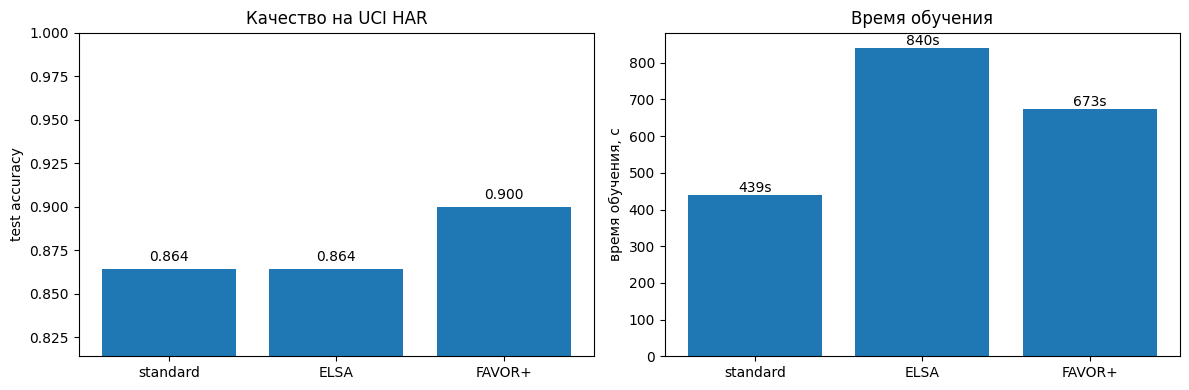

In [14]:
names = list(results.keys())
accs = [results[m]["acc"] for m in names]
times = [results[m]["time"] for m in names]

print(f"{'method':<10}{'test acc':>10}{'train time, s':>16}")
for m in names:
    print(f"{m:<10}{results[m]['acc']:>10.4f}{results[m]['time']:>16.1f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(names, accs)
ax[0].set_ylabel("test accuracy")
ax[0].set_ylim(min(accs) - 0.05, 1.0)
ax[0].set_title("Качество на UCI HAR")
for i, a in enumerate(accs):
    ax[0].text(i, a + 0.005, f"{a:.3f}", ha="center")

ax[1].bar(names, times)
ax[1].set_ylabel("время обучения, с")
ax[1].set_title("Время обучения")
for i, t in enumerate(times):
    ax[1].text(i, t, f"{t:.0f}s", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## Выводы

| механизм | проверка эквивалентности | test acc на HAR | время обучения |
|---|---|---|---|
| standard | эталон | 0.8639 | 439 с |
| ELSA | max\|standard − ELSA\| = 2.8e-07 | 0.8639 | 840 с |
| FAVOR+ | max\|standard − FAVOR+\| = 2.10 | 0.8996 | 673 с |

ELSA воспроизводить softmax точно. Память линейна. Python медленный из-за циклов, поэтому проигрывает по скорости.
